# Experiment 4 — Transformer for Language Translation

## Aim
To implement and evaluate an encoder–decoder Transformer for English-to-French translation without using a pretrained translation pipeline.

## Objectives

1. Prepare a parallel corpus and training-only vocabularies.
2. Combine embeddings, sinusoidal positions, multi-head attention, feed-forward layers, residual paths, and layer normalization.
3. Apply causal masking in the decoder and padding masks throughout.
4. Report loss curves, corpus BLEU, and actual-versus-predicted translations.

## 1–4. Required libraries and configurable setup

In [1]:
import math, os, random, re, time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu

CONFIG = {
    "train_samples": 4000, "val_samples": 500, "test_samples": 500,
    "batch_size": 64, "learning_rate": 8e-4, "epochs": 25,
    "embedding_dim": 128, "hidden_dim": 256, "attention_heads": 4,
    "encoder_layers": 2, "decoder_layers": 2, "dropout": 0.1,
    "max_sequence_length": 22, "min_frequency": 2,
}
CONFIG

Using device: cuda


{'train_samples': 4000,
 'val_samples': 500,
 'test_samples': 500,
 'batch_size': 64,
 'learning_rate': 0.0008,
 'epochs': 25,
 'embedding_dim': 128,
 'hidden_dim': 256,
 'attention_heads': 4,
 'encoder_layers': 2,
 'decoder_layers': 2,
 'dropout': 0.1,
 'max_sequence_length': 22,
 'min_frequency': 2}

## Dataset

```text
Dataset: OPUS Books English–French parallel corpus
Dataset source: Hugging Face Datasets — Helsinki-NLP/opus_books, configuration en-fr
Task: English-to-French machine translation
Number of samples: 127,085 aligned sentence pairs in the available corpus
Training samples: CONFIG["train_samples"] after a fixed-seed shuffle
Validation samples: CONFIG["val_samples"] from the same shuffled corpus
Test samples: CONFIG["test_samples"] from the same shuffled corpus
Input format: English sentence (string)
Output format: French sentence (string)
```

The corpus has one official split, so this notebook creates disjoint train/validation/test subsets after a deterministic shuffle. It retains sentence pairs that fit the configured sequence length before taking the subsets; this reduces destructive truncation and makes the small-data lab task learnable. Both languages are lower-cased, regex-tokenized, wrapped with `<bos>`/`<eos>`, numericalized with training-only vocabularies, and padded per batch.

In [2]:
raw = load_dataset("Helsinki-NLP/opus_books", "en-fr", split="train").shuffle(seed=SEED)
total_needed = CONFIG["train_samples"] + CONFIG["val_samples"] + CONFIG["test_samples"]
if total_needed > len(raw):
    raise ValueError("Requested subset exceeds the OPUS Books corpus.")
pairs = []
for row in raw:
    source, target = row["translation"]["en"], row["translation"]["fr"]
    # A conservative whitespace check leaves room for BOS/EOS and punctuation tokens.
    limit = CONFIG["max_sequence_length"] - 4
    if 2 <= len(source.split()) <= limit and 2 <= len(target.split()) <= limit:
        pairs.append((source, target))
    if len(pairs) == total_needed:
        break
if len(pairs) < total_needed:
    raise RuntimeError("Not enough sentence pairs passed the configured length filter.")
n_train, n_val = CONFIG["train_samples"], CONFIG["val_samples"]
train_pairs = pairs[:n_train]
val_pairs = pairs[n_train:n_train+n_val]
test_pairs = pairs[n_train+n_val:]

display(pd.DataFrame({"split": ["train", "validation", "test"],
                      "samples_used": list(map(len, [train_pairs, val_pairs, test_pairs]))}))
display(pd.DataFrame(train_pairs[:3], columns=["English", "French"]))

,split,samples_used
0,train,4000
1,validation,500
2,test,500


,English,French
0,"""Not if it were my own brother!"" cried d’Artag...","«Non, fût-ce mon frère!» s'écria d'Artagnan co..."
1,"""Mr. Conseil put one over on me!""",Monsieur Conseil qui me fait poser !
2,"""It is impossible a gentleman could have writt...","«Mon Dieu! dit-elle, saurait-il...» Et elle s'..."


In [3]:
TOKEN_PATTERN = re.compile(r"[A-Za-zÀ-ÿ']+|[.!?,;:]")

def tokenize(text):
    """Lower-case word/punctuation tokenizer requiring no external model."""
    return TOKEN_PATTERN.findall(text.lower())

class Vocabulary:
    def __init__(self, texts, min_freq=2, specials=("<pad>", "<unk>", "<bos>", "<eos>")):
        counts = Counter(token for text in texts for token in tokenize(text))
        self.itos = list(specials) + sorted(w for w, n in counts.items() if n >= min_freq and w not in specials)
        self.stoi = {word: index for index, word in enumerate(self.itos)}
        self.pad_idx = self.stoi["<pad>"]
        self.unk_idx = self.stoi["<unk>"]
        self.bos_idx = self.stoi["<bos>"]
        self.eos_idx = self.stoi["<eos>"]

    def __len__(self):
        return len(self.itos)

    def encode(self, text, max_length, add_boundaries=True):
        tokens = tokenize(text)
        if add_boundaries:
            tokens = ["<bos>"] + tokens[: max_length - 2] + ["<eos>"]
        else:
            tokens = tokens[:max_length]
        return [self.stoi.get(token, self.unk_idx) for token in tokens]

    def decode(self, ids):
        ignored = {self.pad_idx, self.bos_idx, self.eos_idx}
        return " ".join(self.itos[i] for i in ids if i not in ignored)

src_vocab = Vocabulary((src for src, _ in train_pairs), min_freq=CONFIG["min_frequency"])
tgt_vocab = Vocabulary((tgt for _, tgt in train_pairs), min_freq=CONFIG["min_frequency"])
print(f"English vocabulary: {len(src_vocab):,}; French vocabulary: {len(tgt_vocab):,}")

class TranslationDataset(Dataset):
    def __init__(self, sentence_pairs): self.pairs = sentence_pairs
    def __len__(self): return len(self.pairs)
    def __getitem__(self, index):
        src, tgt = self.pairs[index]
        return (torch.tensor(src_vocab.encode(src, CONFIG["max_sequence_length"])),
                torch.tensor(tgt_vocab.encode(tgt, CONFIG["max_sequence_length"])))

def collate_translation(batch):
    src, tgt = zip(*batch)
    return (nn.utils.rnn.pad_sequence(src, batch_first=True, padding_value=src_vocab.pad_idx),
            nn.utils.rnn.pad_sequence(tgt, batch_first=True, padding_value=tgt_vocab.pad_idx))

loader_kwargs = dict(batch_size=CONFIG["batch_size"], collate_fn=collate_translation)
train_loader = DataLoader(TranslationDataset(train_pairs), shuffle=True, **loader_kwargs,
                          generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(TranslationDataset(val_pairs), **loader_kwargs)
test_loader = DataLoader(TranslationDataset(test_pairs), **loader_kwargs)

English vocabulary: 2,725; French vocabulary: 2,957


## 9–10. Transformer architecture and model summary

Source and shifted target tokens become $d_{model}$-dimensional embeddings and receive sinusoidal positional encodings. Each encoder layer has multi-head self-attention and a position-wise feed-forward network. Each decoder layer adds **masked** self-attention plus cross-attention to encoder memory. PyTorch's `nn.Transformer` implements residual additions and layer normalization around these sublayers; below, we instantiate it directly rather than calling a pretrained translator.

The causal mask contains $-\infty$ above the diagonal, preventing target position $t$ from seeing future target words. Padding masks prevent attention to `<pad>` tokens. A final linear layer predicts a French vocabulary logit vector at each position.

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, dimension, max_length, dropout):
        super().__init__(); self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_length).unsqueeze(1)
        scale = torch.exp(torch.arange(0, dimension, 2) * (-math.log(10000.0) / dimension))
        encoding = torch.zeros(max_length, dimension)
        encoding[:, 0::2] = torch.sin(position * scale)
        encoding[:, 1::2] = torch.cos(position * scale)
        self.register_buffer("encoding", encoding.unsqueeze(0))
    def forward(self, x): return self.dropout(x + self.encoding[:, :x.size(1)])

class TranslationTransformer(nn.Module):
    def __init__(self):
        super().__init__(); d = CONFIG["embedding_dim"]
        self.src_embedding = nn.Embedding(len(src_vocab), d, padding_idx=src_vocab.pad_idx)
        self.tgt_embedding = nn.Embedding(len(tgt_vocab), d, padding_idx=tgt_vocab.pad_idx)
        self.position = PositionalEncoding(d, CONFIG["max_sequence_length"], CONFIG["dropout"])
        self.transformer = nn.Transformer(
            d_model=d, nhead=CONFIG["attention_heads"], num_encoder_layers=CONFIG["encoder_layers"],
            num_decoder_layers=CONFIG["decoder_layers"], dim_feedforward=CONFIG["hidden_dim"],
            dropout=CONFIG["dropout"], batch_first=True, norm_first=True)
        self.output = nn.Linear(d, len(tgt_vocab))
    def encode(self, src):
        src_pad = src.eq(src_vocab.pad_idx)
        embedded = self.position(self.src_embedding(src) * math.sqrt(CONFIG["embedding_dim"]))
        return self.transformer.encoder(embedded, src_key_padding_mask=src_pad), src_pad
    def decode(self, tgt, memory, src_pad):
        tgt_pad = tgt.eq(tgt_vocab.pad_idx)
        mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1), device=tgt.device)
        embedded = self.position(self.tgt_embedding(tgt) * math.sqrt(CONFIG["embedding_dim"]))
        decoded = self.transformer.decoder(embedded, memory, tgt_mask=mask,
                                           tgt_key_padding_mask=tgt_pad, memory_key_padding_mask=src_pad)
        return self.output(decoded)
    def forward(self, src, tgt):
        memory, src_pad = self.encode(src)
        return self.decode(tgt, memory, src_pad)

model = TranslationTransformer().to(DEVICE)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

TranslationTransformer(
  (src_embedding): Embedding(2725, 128, padding_idx=0)
  (tgt_embedding): Embedding(2957, 128, padding_idx=0)
  (position): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )


/home/kabilash01/miniconda3/envs/dl/lib/python3.10/site-packages/torch/nn/modules/transformer.py:143: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(


## 11–12. Training and validation

/home/kabilash01/miniconda3/envs/dl/lib/python3.10/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch 01 | train 6.1414 | validation 4.8724 | 0.7s


Epoch 02 | train 5.0910 | validation 4.6330 | 0.4s


Epoch 03 | train 4.8199 | validation 4.4617 | 0.4s


Epoch 04 | train 4.5729 | validation 4.2981 | 0.4s


...

Epoch 21 | train 2.8525 | validation 3.9036 | 0.4s


Epoch 22 | train 2.7914 | validation 3.9275 | 0.4s


Epoch 23 | train 2.7374 | validation 3.9296 | 0.4s


Epoch 24 | train 2.6712 | validation 3.9416 | 0.4s


Epoch 25 | train 2.6246 | validation 3.9396 | 0.4s


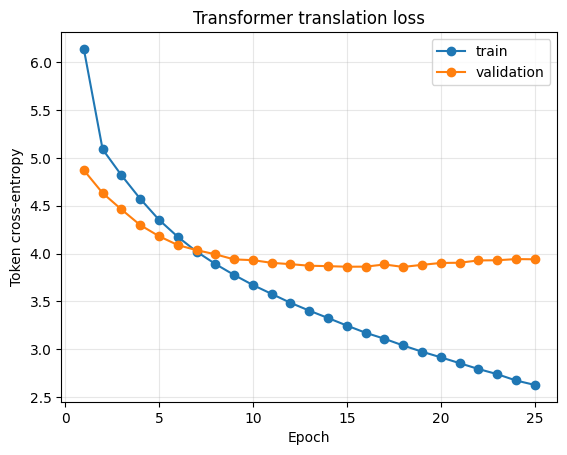

In [5]:
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab.pad_idx)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], betas=(0.9, 0.98))

def transformer_loss(loader, training):
    model.train(training); total, tokens = 0.0, 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE); prefix, gold = tgt[:, :-1], tgt[:, 1:]
        if training: optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            logits = model(src, prefix)
            loss = criterion(logits.reshape(-1, len(tgt_vocab)), gold.reshape(-1))
            if training:
                loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
        count = gold.ne(tgt_vocab.pad_idx).sum().item(); total += loss.item()*count; tokens += count
    return total/tokens

history={"train_loss": [], "val_loss": []}; best_state, best_loss=None, float("inf")
for epoch in range(1, CONFIG["epochs"]+1):
    started=time.time(); train_loss=transformer_loss(train_loader, True); val_loss=transformer_loss(val_loader, False)
    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    if val_loss < best_loss:
        best_loss=val_loss; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    print(f"Epoch {epoch:02d} | train {train_loss:.4f} | validation {val_loss:.4f} | {time.time()-started:.1f}s")
model.load_state_dict(best_state)

plt.plot(range(1, CONFIG["epochs"]+1), history["train_loss"], marker="o", label="train")
plt.plot(range(1, CONFIG["epochs"]+1), history["val_loss"], marker="o", label="validation")
plt.xlabel("Epoch"); plt.ylabel("Token cross-entropy"); plt.title("Transformer translation loss")
plt.grid(alpha=.3); plt.legend(); plt.show()

## 13–15. BLEU and actual-versus-predicted translations

In [6]:
@torch.no_grad()
def translate(sentence):
    model.eval()
    src = torch.tensor(src_vocab.encode(sentence, CONFIG["max_sequence_length"]), device=DEVICE).unsqueeze(0)
    memory, src_pad = model.encode(src); generated = [tgt_vocab.bos_idx]
    for _ in range(CONFIG["max_sequence_length"]-1):
        prefix = torch.tensor(generated, device=DEVICE).unsqueeze(0)
        next_id = model.decode(prefix, memory, src_pad)[0, -1].argmax().item()
        if next_id == tgt_vocab.eos_idx: break
        generated.append(next_id)
    return tgt_vocab.decode(generated)

references, hypotheses, examples = [], [], []
for source, target in test_pairs:
    prediction = translate(source)
    references.append([tokenize(target)]); hypotheses.append(tokenize(prediction))
    if len(examples) < 10: examples.append((source, target, prediction))
bleu = corpus_bleu(references, hypotheses, smoothing_function=SmoothingFunction().method1)
print(f"Corpus BLEU on {len(test_pairs)} test pairs: {bleu:.4f}")
display(pd.DataFrame(examples, columns=["English source", "Actual French", "Transformer prediction"]))

Corpus BLEU on 500 test pairs: 0.0143


,English source,Actual French,Transformer prediction
0,How could he claim it without causing suspicio...,Comment aurait-il pu revendiquer l’héritage sa...,et il <unk> ?
1,The yellow curtains along the windows let a he...,"Les rideaux jaunes, le long des fenêtres laiss...","<unk> , <unk> <unk> <unk> <unk> , <unk> <unk> ..."
2,"Pencroft had torn up his shirt, and was mechan...","Pencroff avait déchiré sa chemise, et, machina...","son <unk> , <unk> , <unk> , <unk> , <unk> , <u..."
3,And that he should have such a strapping son a...,"Et qu'il a, pour continuer la race des Avon, u...","il se <unk> , et il <unk> !"
4,"'Go,' said Madame de Renal.","– Allez, dit Mme de Rênal.","non , dit d'artagnan , dit d'artagnan , dit d'..."
5,And argued each case with my wife;,Tous les jours avec votre mère ;,"mon ami , et <unk> , et <unk> ."
6,They both remained stupefied.,Toutes deux resterent béantes.,ils <unk> <unk> <unk> .
7,His ordinary occupations were neglected or for...,"Ses occupations habituelles étaient négligées,...",<unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk...
8,"""No less,"" said Athos, as pale as a corpse.","Mais on me laisse manquer de vin, ce me semble.»","non , dit d'artagnan , dit d'artagnan , dit d'..."
9,"I saw them the night before last.""",Je les ai vus avant-hier au soir.,"je <unk> , <unk> <unk> <unk> <unk> <unk> <unk>..."


## 16–17. Results and conclusion

The plotted losses, BLEU score, and example translations are computed by this run. This experiment demonstrates the complete encoder–decoder information flow: encoder self-attention creates source memory, causal decoder self-attention models the generated prefix, and cross-attention retrieves source information. The deliberately small word-level setup is suitable for inspection and viva explanation; subwords, a larger corpus, learning-rate warm-up, and beam search would improve a production system.